Diabetes Prediction using Machine Learning

Objective

The objective of this project is to analyze whether K-Nearest Neighbors (KNN) is suitable for the diabetes prediction dataset and compare its performance with other machine learning algorithms.

In [1]:
#step 1: import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#step 2: load the dataset

import kagglehub
import os

# Download dataset from Kaggle
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

# Load dataset
file_path = os.path.join(path, "diabetes_prediction_dataset.csv")
df = pd.read_csv(file_path)

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [4]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Step 4: Data Visualization
Diabetes Distribution

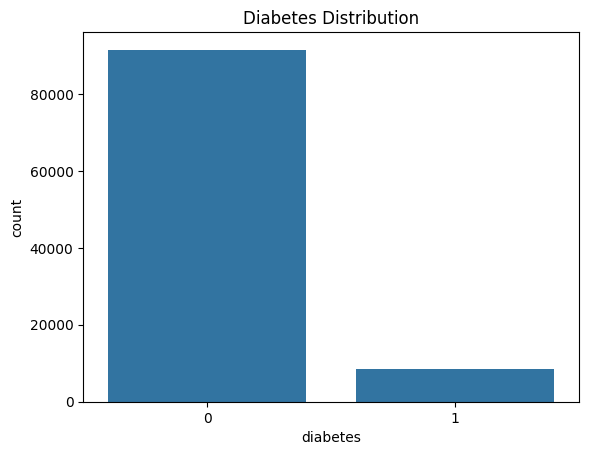

In [5]:
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Distribution")
plt.show()

Correlation Matrix (Numerical Features)

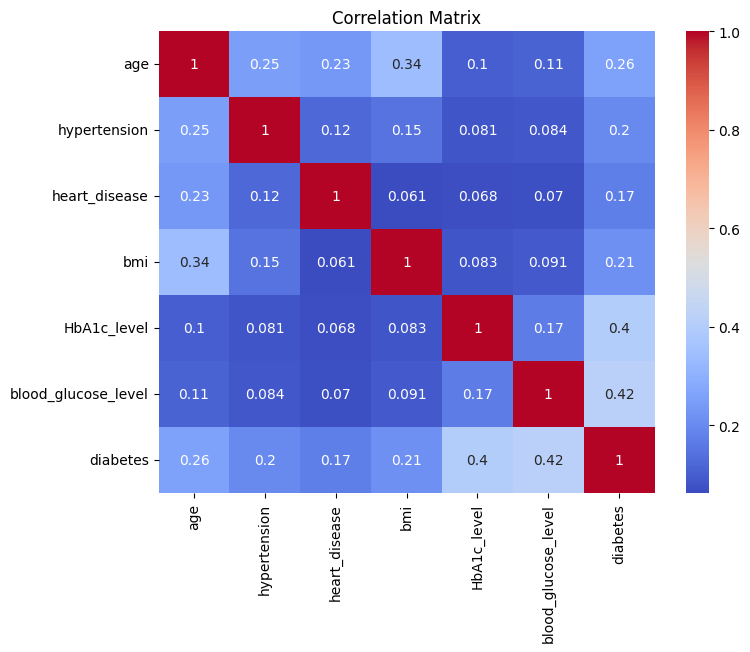

In [6]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Step 5: Data Preprocessing
Convert Categorical Columns

In [7]:
df = pd.get_dummies(df, columns=['gender','smoking_history'], drop_first=True)

Split Features & Target

In [8]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Feature Scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 6: Model 1 — KNN

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.9605
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.89      0.61      0.73      1708

    accuracy                           0.96     20000
   macro avg       0.93      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



Step 7: Model 2 — Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.95905
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



Step 8: Model 3 — Random Forest

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9699
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



Step 9: Model Comparison

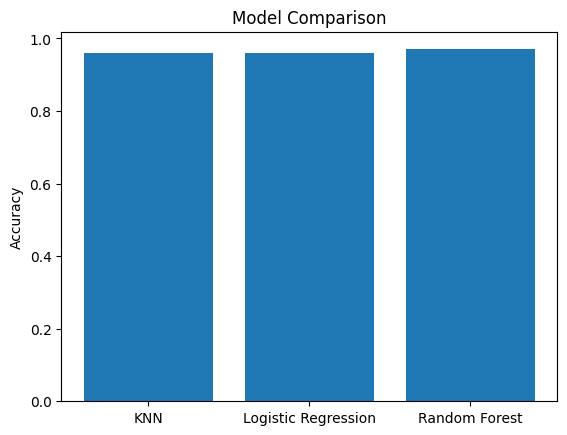

In [14]:
models = ['KNN','Logistic Regression','Random Forest']

accuracies = [
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred)
]

plt.bar(models, accuracies)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

Final Conclusion
Conclusion

K-Nearest Neighbors (KNN) performed reasonably well on this dataset due to the numerical nature of the features. However, it required feature scaling and was sensitive to noise and outliers.

Logistic Regression provided stable performance and is highly interpretable, making it useful in healthcare scenarios.

Random Forest outperformed both KNN and Logistic Regression in terms of accuracy and robustness. It handled non-linear relationships effectively and was less sensitive to noise.

Final Verdict:
KNN is a good baseline model but not the best choice.
Logistic Regression is suitable when interpretability is important.
Random Forest performs best due to higher accuracy and robustness.